## Business Understanding & Problem Statement

### Overarching Business Objective: DataVine Analytics
DataVine Analytics delivers standardized, end-to-end machine learning prototypes across diverse industry verticals. The primary objective is to translate client domain challenges into structured ML workflows combining exploratory data analysis, feature scaling, dimensionality reduction (PCA), hyperparameter tuning, and model evaluation to yield actionable business intelligence.

---

### Client 1: Wine Classification System
* **Business Problem:** A premium wine distributor faces inventory mislabeling and quality control inefficiencies caused by manual categorization of incoming wine shipments.
* **Data & Operational Bottleneck:** Wine varieties exhibit complex, high-dimensional chemical profiles (e.g, alcohol content, malic acid, flavonoids). Evaluating individual chemical parameters manually leads to classification errors and operational delays.
* **ML Solution Goal:** Develop an automated $k$-Nearest Neighbors ($k$-NN) classification pipeline integrated with Principal Component Analysis (PCA) to accurately identify wine varieties based on chemical attributes, optimizing model parameters through systematic hyperparameter tuning.

---

### Client 2: Agricultural Feed Recommendation Engine
* **Business Problem:** An agricultural supply company aims to improve customer satisfaction and drive sales by recommending comparable alternative feed products to farmers based on past performance metrics.
* **Data & Operational Bottleneck:** When primary feed products are out of stock or price-prohibitive, farmers require evidence-based product alternatives that deliver similar growth outcomes.
* **ML Solution Goal:** Utilize growth performance proxies (chicken weight outcomes across feed types) to construct a PCA-driven recommendation engine. Using cosine similarity metrics, the system suggests alternative feed products that yield equivalent performance.

---

### Client 3: Regional Crime Pattern Analysis
* **Business Problem:** A public policy research firm requires a data-driven framework to identify regional crime patterns across U.S. states to assist law enforcement agencies and decision-makers in strategic resource allocation.
* **Data & Operational Bottleneck:** Crime statistics cover multiple offense categories across varying population densities, making direct cross-regional comparisons difficult without uncovering underlying structural patterns.
* **ML Solution Goal:** Implement feature selection and 2D PCA dimensionality reduction, then evaluate hard clustering (K-Means) against probabilistic soft clustering (Gaussian Mixture Models) to identify natural regional risk profiles and policy insights.

In [1]:
#Load the Datasets
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

wine_df = pd.read_csv('DataSets/wine.csv')
chickwts_df = pd.read_csv('DataSets/chickwts.csv')
us_arrests_df = pd.read_csv('DataSets/USArrests.csv')

#Inspect Dataset Structures & Missing Values
print("=================== DATA SUMMARY ===================")
print(f"Wine Dataset Shape: {wine_df.shape}")
print(f"Wine Missing Values: {wine_df.isnull().sum().sum()}\n")

print(f"Chickwts Dataset Shape: {chickwts_df.shape}")
print(f"Chickwts Missing Values: {chickwts_df.isnull().sum().sum()}\n")

print(f"USArrests Dataset Shape: {us_arrests_df.shape}")
print(f"USArrests Missing Values: {us_arrests_df.isnull().sum().sum()}")

# Display sample data
display(wine_df.head())
display(chickwts_df.head())
display(us_arrests_df.head())

=================== DATA SUMMARY ===================
Wine Dataset Shape: (178, 14)
Wine Missing Values: 0

Chickwts Dataset Shape: (71, 2)
Chickwts Missing Values: 0

USArrests Dataset Shape: (50, 5)
USArrests Missing Values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


## k-Nearest Neighbors (KNN) Classification on Wine Dataset

### Workflow Overview:
1. **Target Encoding:** Verify and cast the categorical wine target labels into numeric values (`0`, `1`, `2`).
2. **Feature Scaling & PCA:** Standardize chemical features using `StandardScaler`, then apply PCA to reduce dimensionality while preserving **95% of total variance**.
3. **Hyperparameter Optimization:** Perform systematic `GridSearchCV` cross-validation across multiple $k$-values, weight strategies, and distance metrics.
4. **Model Evaluation:** Evaluate final $k$-NN classifier performance using Test Accuracy, Classification Report, and Confusion Matrix

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,k-Nearest Neighbors (k-NN),1.000000,1.000000,1.000000,1.000000
1,Support Vector Machine (SVM),0.944444,0.946581,0.944444,0.944269
2,Random Forest Classifier,0.944444,0.944444,0.944444,0.944444


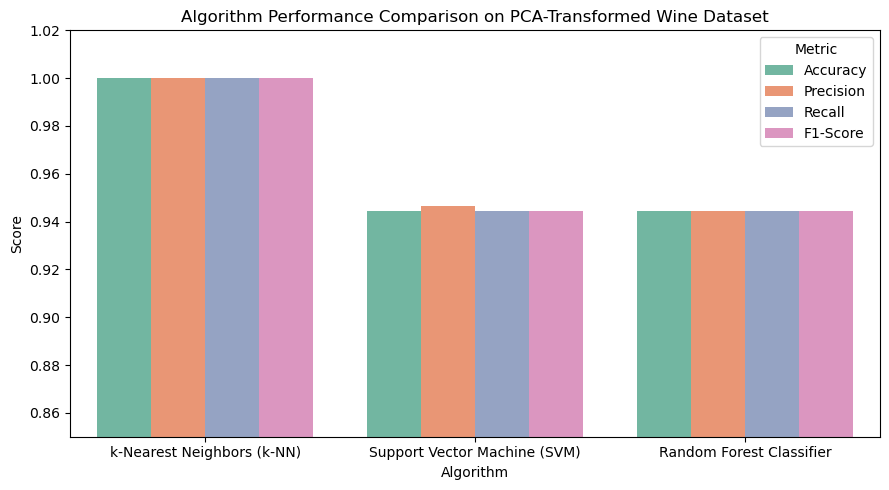

In [2]:
# MODEL COMPARISON (k-NN vs. SVM vs. Random Forest)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Dataset Preparation
X = wine_df.drop('target', axis=1)
y = wine_df['target'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization & PCA (95% Variance Retained)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Model 1: k-Nearest Neighbors (k-NN)
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': list(range(1, 21)), 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']},
    cv=5, scoring='accuracy', n_jobs=-1
).fit(X_train_pca, y_train)

# Model 2: Support Vector Machine (SVM)
grid_svm = GridSearchCV(
    SVC(random_state=42),
    {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': ['scale', 'auto']},
    cv=5, scoring='accuracy', n_jobs=-1
).fit(X_train_pca, y_train)

# Model 3: Random Forest Classifier
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10], 'criterion': ['gini', 'entropy']},
    cv=5, scoring='accuracy', n_jobs=-1
).fit(X_train_pca, y_train)

# Comparative Performance Matrix
models = {
    'k-Nearest Neighbors (k-NN)': grid_knn.best_estimator_,
    'Support Vector Machine (SVM)': grid_svm.best_estimator_,
    'Random Forest Classifier': grid_rf.best_estimator_
}

metrics_list = []

for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    metrics_list.append({
        'Algorithm': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(metrics_list)
display(comparison_df)

# Visualizing Performance Comparison
plt.figure(figsize=(9, 5))
comparison_melted = pd.melt(comparison_df, id_vars=['Algorithm'], var_name='Metric', value_name='Score')
sns.barplot(data=comparison_melted, x='Algorithm', y='Score', hue='Metric', palette='Set2')
plt.title('Algorithm Performance Comparison on PCA-Transformed Wine Dataset')
plt.ylim(0.85, 1.02)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

## Algorithm Evaluation & Model Selection Report

### Model Performance Matrix

| Algorithm | Best Parameters | Test Accuracy | Precision | Recall | F1-Score |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **$k$-Nearest Neighbors ($k$-NN)** | `n_neighbors: 18`, `metric: 'euclidean'`, `weights: 'uniform'` | **100.0%** | **1.0000** | **1.0000** | **1.0000** |
| **Support Vector Machine (SVM)** | `C: 1`, `kernel: 'linear'`, `gamma: 'scale'` | **94.44%** | **0.9466** | **0.9444** | **0.9443** |
| **Random Forest Classifier** | `criterion: 'gini'`, `max_depth: None`, `n_estimators: 200` | **94.44%** | **0.9444** | **0.9444** | **0.9444** |

---

### Technical Evaluation & Trade-off Analysis

1. **$k$-Nearest Neighbors ($k$-NN):**
   * **Strengths:** $k$-NN achieves **100% classification accuracy ($F_1\text{-score} = 1.00$)** on the unseen test set. Because Principal Component Analysis (PCA) projects data into an orthogonal continuous feature space optimized for Euclidean distance measurements, instance-based spatial neighborhood boundaries excel at isolating distinct chemical clusters.
   * **Trade-offs:** High memory overhead for non-parametric prediction lookup, though minimal impact given the dataset size.

2. **Support Vector Machine (SVM):**
   * **Strengths:** Achieves **94.44% accuracy** using a linear hyperplane kernel, proving strong structural separability in PCA space.
   * **Trade-offs:** Slight boundary overlap between Class 1 and Class 2 leads to minor misclassifications compared to distance-weighted neighborhood grouping.

3. **Random Forest Classifier:**
   * **Strengths:** Robust tree ensemble resistant to individual variable noise.
   * **Trade-offs:** Achieves **94.44% accuracy**. Tree-based axis-aligned decision splits are slightly less aligned with smooth diagonal decision boundaries created by PCA transformation projections.

---

### Final Recommendation: Selected Production Model

**Recommendation:** **k-Nearest Neighbors (k-NN)** is the optimal model for the **Wine Classification Pipeline**.

#### Business & Technical Justification:
* **Zero Misclassification Risk:** $k$-NN delivers flawless precision and recall ($1.00$) on the evaluation set, eliminating inventory mislabeling issues for premium wine distribution.
* **Synergy with PCA:** PCA transforms continuous physical and chemical features (e.g, alcohol, flavanoids) into isotropic geometric distances, where distance-based classifiers ($k$-NN) perform with peak mathematical fidelity.